# 2. Optimización y Evaluación de Ensambles de Árboles para Predicción de Riesgo de Sobrecosto

**Proyecto:** Predicción Temprana del Riesgo de Sobrecosto en Contratos de Medicamentos — EsSalud
**Módulo:** Partición estratificada, Grid Search con Stratified K-Fold CV, evaluación rigurosa y visualización comparativa (XGBoost vs. Random Forest)

---

## Índice de Contenido

1. [Fundamento Teórico: Boosting vs. Bagging](#1.-Fundamento-Teórico:-Boosting-vs.-Bagging)
2. [Carga de la Matriz Enriquecida](#2.-Carga-de-la-Matriz-Enriquecida)
3. [Partición Estratificada 80/20](#3.-Partición-Estratificada-80/20)
4. [Grid Search + Stratified K-Fold CV — XGBoost](#4.-Grid-Search-+-Stratified-K-Fold-CV-—-XGBoost)
5. [Grid Search + Stratified K-Fold CV — Random Forest](#5.-Grid-Search-+-Stratified-K-Fold-CV-—-Random-Forest)
6. [Evaluación Rigurosa en el Conjunto de Prueba](#6.-Evaluación-Rigurosa-en-el-Conjunto-de-Prueba)
7. [Visualización: Importancia de Características](#7.-Visualización:-Importancia-de-Características)
8. [Visualización: Distribución de Lead Time por Clase (KDE)](#8.-Visualización:-Distribución-de-Lead-Time-por-Clase-(KDE))
9. [Visualización: Curvas ROC y Precision-Recall](#9.-Visualización:-Curvas-ROC-y-Precision-Recall)
10. [Visualización: Matriz de Confusión Normalizada](#10.-Visualización:-Matriz-de-Confusión-Normalizada)
11. [Visualización: Comparativa de Métricas Finales](#11.-Visualización:-Comparativa-de-Métricas-Finales)
12. [Serialización de Artefactos](#12.-Serialización-de-Artefactos)


## 1. Fundamento Teórico: Boosting vs. Bagging

Los dos estimadores de ensamble seleccionados representan las dos familias dominantes en el aprendizaje sobre datos tabulares estructurados:

**Random Forest (Bagging paralelo).** Construye $B$ árboles de decisión de forma **independiente** sobre muestras bootstrap del conjunto de entrenamiento, seleccionando en cada nodo un subconjunto aleatorio de `max_features` variables. La predicción final es el voto mayoritario (clasificación). Matemáticamente, reduce la **varianza** del estimador mediante promediación:

$$\hat{f}_{RF}(x) = \frac{1}{B}\sum_{b=1}^{B} T_b(x)$$

Su fortaleza ante variables de Lead Time reside en la robustez frente a relaciones no monótonas o umbrales de riesgo discontinuos (p. ej., "más de 90 días de formalización dispara el riesgo, pero entre 0 y 90 el efecto es marginal").

**XGBoost (Gradient Boosting regularizado).** Construye árboles de forma **secuencial**, donde cada árbol $T_m$ ajusta los **residuos del gradiente** (pseudo-residuos) de la función de pérdida acumulada por los árboles previos:

$$\hat{f}_m(x) = \hat{f}_{m-1}(x) + \eta \cdot T_m(x)$$

incorporando términos de regularización $L_1$ (`reg_alpha`) y $L_2$ (`reg_lambda`) sobre los pesos de las hojas para controlar el sobreajuste — crítico dado el tamaño moderado de la muestra (12,500 registros) y el desbalance de clases. Boosting reduce primordialmente el **sesgo**, siendo especialmente sensible a capturar interacciones finas entre `lead_time_formalizacion` y variables categóricas como `es_uso_critico`, dado su mecanismo de optimización secuencial de residuos.

La comparación empírica de ambos frente a las variables de Lead Time permite contrastar si el riesgo de sobrecosto responde a una señal de **umbral duro** (favorece Random Forest) o a una **interacción gradual acumulativa** (favorece XGBoost).


## 2. Carga de la Matriz Enriquecida

Se carga `medicine_overrun_dataset.csv`, generado íntegramente por el Notebook 1, verificando la ausencia de fugas residuales (columnas de fecha) y la correcta tipificación numérica de todas las variables predictoras.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
import category_encoders as ce
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

df = pd.read_csv('../data/medicine_overrun_dataset.csv')
print(f"Dimensiones: {df.shape[0]} registros x {df.shape[1]} columnas")
df.head()

Dimensiones: 12500 registros x 36 columnas


,lead_time_adjudicacion,lead_time_formalizacion,lead_time_total_proceso,es_consorcio,es_uso_critico,es_uso_intrahospitalario,monto_adjudicado_soles,anio,red_asistencial_red asistencial arequipa,red_asistencial_red asistencial la libertad,...,tipo_proveedor_natural person,tipo_proceso_seleccion_contratacion directa,tipo_proceso_seleccion_licitacion publica,tipo_proceso_seleccion_subasta inversa electronica,denominacion_dci_target_enc,lead_time_adjudicacion_raw,lead_time_formalizacion_raw,lead_time_total_proceso_raw,monto_adjudicado_soles_raw,flag_tiene_adenda
0,-0.555556,0.000000,-0.357143,0,0,0,-0.312027,2022,False,False,...,False,False,False,False,0.161465,13.0,20.0,33,101165.11,0
1,0.814815,1.470588,1.119048,0,0,1,0.602282,2023,False,False,...,False,False,True,False,0.180543,50.0,45.0,95,694535.50,1
2,0.074074,2.088235,0.976190,0,1,1,-0.377207,2022,False,False,...,False,False,True,False,0.305069,30.0,55.5,89,58864.57,0
3,0.407407,0.764706,0.571429,1,1,1,-0.430313,2025,False,False,...,False,False,True,False,0.282110,39.0,33.0,72,24399.68,0
4,-0.111111,-0.529412,-0.285714,0,0,1,-0.163508,2023,False,False,...,False,False,False,False,0.282110,25.0,11.0,36,197551.31,0


## 3. Partición Estratificada 80/20

Dado el desbalance observado en `flag_tiene_adenda` (≈77% / 23%), se aplica `train_test_split` con `stratify=y`, garantizando que ambas particiones conserven la proporción original de clases. Se reservan las columnas `_raw` (crudas, no escaladas) exclusivamente para fines de visualización interpretativa posterior, excluyéndolas del conjunto de features de entrenamiento (`X`) para evitar redundancia con sus contrapartes escaladas.


In [2]:
target_col = 'flag_tiene_adenda'
raw_cols = [c for c in df.columns if c.endswith('_raw')]

feature_cols = [c for c in df.columns if c not in raw_cols + [target_col]]

X = df[feature_cols].copy()
y = df[target_col].copy()
X_raw_reference = df[raw_cols].copy()  # solo para EDA/visualización

X_train, X_test, y_train, y_test, raw_train, raw_test = train_test_split(
    X, y, X_raw_reference, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros")
print("\nBalance de clases — Train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nBalance de clases — Test:")
print(y_test.value_counts(normalize=True).round(4))

Train: 10000 registros | Test: 2500 registros

Balance de clases — Train:
flag_tiene_adenda
0    0.7717
1    0.2283
Name: proportion, dtype: float64

Balance de clases — Test:
flag_tiene_adenda
0    0.7716
1    0.2284
Name: proportion, dtype: float64


## 4. Grid Search + Stratified K-Fold CV — XGBoost

Se ejecuta una búsqueda exhaustiva por fuerza bruta con `ParameterGrid`, evaluando cada combinación de hiperparámetros mediante **validación cruzada estratificada K-Fold (K=5)** sobre el conjunto de entrenamiento (80%), maximizando el **F1-Score promedio** entre folds como criterio de selección — métrica adecuada frente al desbalance de clases, al equilibrar precisión y exhaustividad sobre la clase minoritaria (contratos con adenda).

El espacio de búsqueda cubre `learning_rate` (tasa de aprendizaje del boosting), `max_depth` (complejidad de cada árbol base), `n_estimators` (número de rondas de boosting) y los términos de regularización `reg_alpha` ($L_1$) y `reg_lambda` ($L_2$).


In [3]:
xgb_param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [150, 300],
    'reg_alpha': [0, 0.5],
    'reg_lambda': [1, 2],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def grid_search_cv(model_class, param_grid, X_tr, y_tr, base_kwargs=None):
    base_kwargs = base_kwargs or {}
    best_score, best_params, best_model = -1, None, None
    results_log = []

    for params in ParameterGrid(param_grid):
        fold_f1 = []
        for train_idx, val_idx in skf.split(X_tr, y_tr):
            X_fold_tr, X_fold_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
            y_fold_tr, y_fold_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]

            model = model_class(**{**base_kwargs, **params})
            model.fit(X_fold_tr, y_fold_tr)
            preds = model.predict(X_fold_val)
            fold_f1.append(f1_score(y_fold_val, preds))

        mean_f1 = np.mean(fold_f1)
        results_log.append({**params, 'mean_f1_cv': mean_f1})

        if mean_f1 > best_score:
            best_score, best_params = mean_f1, params

    final_model = model_class(**{**base_kwargs, **best_params})
    final_model.fit(X_tr, y_tr)
    return final_model, best_params, best_score, pd.DataFrame(results_log)

xgb_base_kwargs = dict(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False)

best_xgb, best_xgb_params, best_xgb_cv_f1, xgb_grid_log = grid_search_cv(
    XGBClassifier, xgb_param_grid, X_train, y_train, base_kwargs=xgb_base_kwargs
)

print(f"Mejores hiperparámetros XGBoost: {best_xgb_params}")
print(f"F1-Score promedio (5-Fold CV): {best_xgb_cv_f1:.4f}")
xgb_grid_log.sort_values('mean_f1_cv', ascending=False).head(10)

Mejores hiperparámetros XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 1}
F1-Score promedio (5-Fold CV): 0.6808


,learning_rate,max_depth,n_estimators,reg_alpha,reg_lambda,mean_f1_cv
20,0.10,3,300,0.0,1,0.680788
21,0.10,3,300,0.0,2,0.678774
22,0.10,3,300,0.5,1,0.677704
23,0.10,3,300,0.5,2,0.677303
14,0.05,5,300,0.5,1,0.675167
5,0.05,3,300,0.0,2,0.674581
4,0.05,3,300,0.0,1,0.674254
16,0.10,3,150,0.0,1,0.673835
18,0.10,3,150,0.5,1,0.673521
27,0.10,5,150,0.5,2,0.673406


## 5. Grid Search + Stratified K-Fold CV — Random Forest

Se replica el protocolo de búsqueda exhaustiva sobre el estimador de Bagging, explorando `n_estimators` (número de árboles independientes), `max_depth` (profundidad máxima por árbol), `min_samples_split` (control de sobreajuste local) y `max_features` (fracción de variables candidatas por partición, mecanismo central de decorrelación entre árboles en Random Forest).


In [4]:
rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 0.5],
}

rf_base_kwargs = dict(random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1)

best_rf, best_rf_params, best_rf_cv_f1, rf_grid_log = grid_search_cv(
    RandomForestClassifier, rf_param_grid, X_train, y_train, base_kwargs=rf_base_kwargs
)

print(f"Mejores hiperparámetros Random Forest: {best_rf_params}")
print(f"F1-Score promedio (5-Fold CV): {best_rf_cv_f1:.4f}")
rf_grid_log.sort_values('mean_f1_cv', ascending=False).head(10)

Mejores hiperparámetros Random Forest: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
F1-Score promedio (5-Fold CV): 0.6838


,max_depth,max_features,min_samples_split,n_estimators,mean_f1_cv
2,8.0,sqrt,5,200,0.683821
1,8.0,sqrt,2,400,0.683037
0,8.0,sqrt,2,200,0.682874
10,12.0,sqrt,5,200,0.681856
3,8.0,sqrt,5,400,0.681738
11,12.0,sqrt,5,400,0.681564
14,12.0,0.5,5,200,0.678974
6,8.0,0.5,5,200,0.678904
9,12.0,sqrt,2,400,0.677975
5,8.0,0.5,2,400,0.677666


## 6. Evaluación Rigurosa en el Conjunto de Prueba

Ambos modelos óptimos (seleccionados por F1-Score en validación cruzada) se evalúan sobre el **20% de prueba** —nunca visto durante el ajuste de hiperparámetros—, calculando la matriz completa de métricas: Accuracy, Precision, Recall, F1-Score, ROC-AUC y la Matriz de Confusión.


In [5]:
def evaluate_model(model, X_te, y_te, name):
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Modelo': name,
        'Accuracy': accuracy_score(y_te, preds),
        'Precision': precision_score(y_te, preds),
        'Recall': recall_score(y_te, preds),
        'F1-Score': f1_score(y_te, preds),
        'ROC-AUC': roc_auc_score(y_te, proba),
    }
    cm = confusion_matrix(y_te, preds)
    return metrics, cm, preds, proba

xgb_metrics, xgb_cm, xgb_preds, xgb_proba = evaluate_model(best_xgb, X_test, y_test, 'XGBoost')
rf_metrics, rf_cm, rf_preds, rf_proba = evaluate_model(best_rf, X_test, y_test, 'Random Forest')

results_df = pd.DataFrame([xgb_metrics, rf_metrics]).set_index('Modelo').round(4)
print("=== Matriz de Evaluación Comparativa — Conjunto de Prueba (20%) ===")
print(results_df)

print("\n=== Matriz de Confusión — XGBoost ===")
print(xgb_cm)
print("\n=== Matriz de Confusión — Random Forest ===")
print(rf_cm)

best_model_name = results_df['F1-Score'].idxmax()
best_model = best_xgb if best_model_name == 'XGBoost' else best_rf
best_cm = xgb_cm if best_model_name == 'XGBoost' else rf_cm
best_proba = xgb_proba if best_model_name == 'XGBoost' else rf_proba
print(f"\nModelo final seleccionado por F1-Score en prueba: {best_model_name}")

=== Matriz de Evaluación Comparativa — Conjunto de Prueba (20%) ===
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                       
XGBoost          0.8584     0.7275  0.6077    0.6622   0.8951
Random Forest    0.8396     0.6257  0.7408    0.6784   0.8767

=== Matriz de Confusión — XGBoost ===
[[1799  130]
 [ 224  347]]

=== Matriz de Confusión — Random Forest ===
[[1676  253]
 [ 148  423]]

Modelo final seleccionado por F1-Score en prueba: Random Forest


## 7. Visualización: Importancia de Características

Se generan gráficas independientes de importancia de características (`feature_importances_`) para cada ensamble, con particular atención al peso relativo ocupado por las tres variables de Lead Time frente al resto de predictores del sistema.


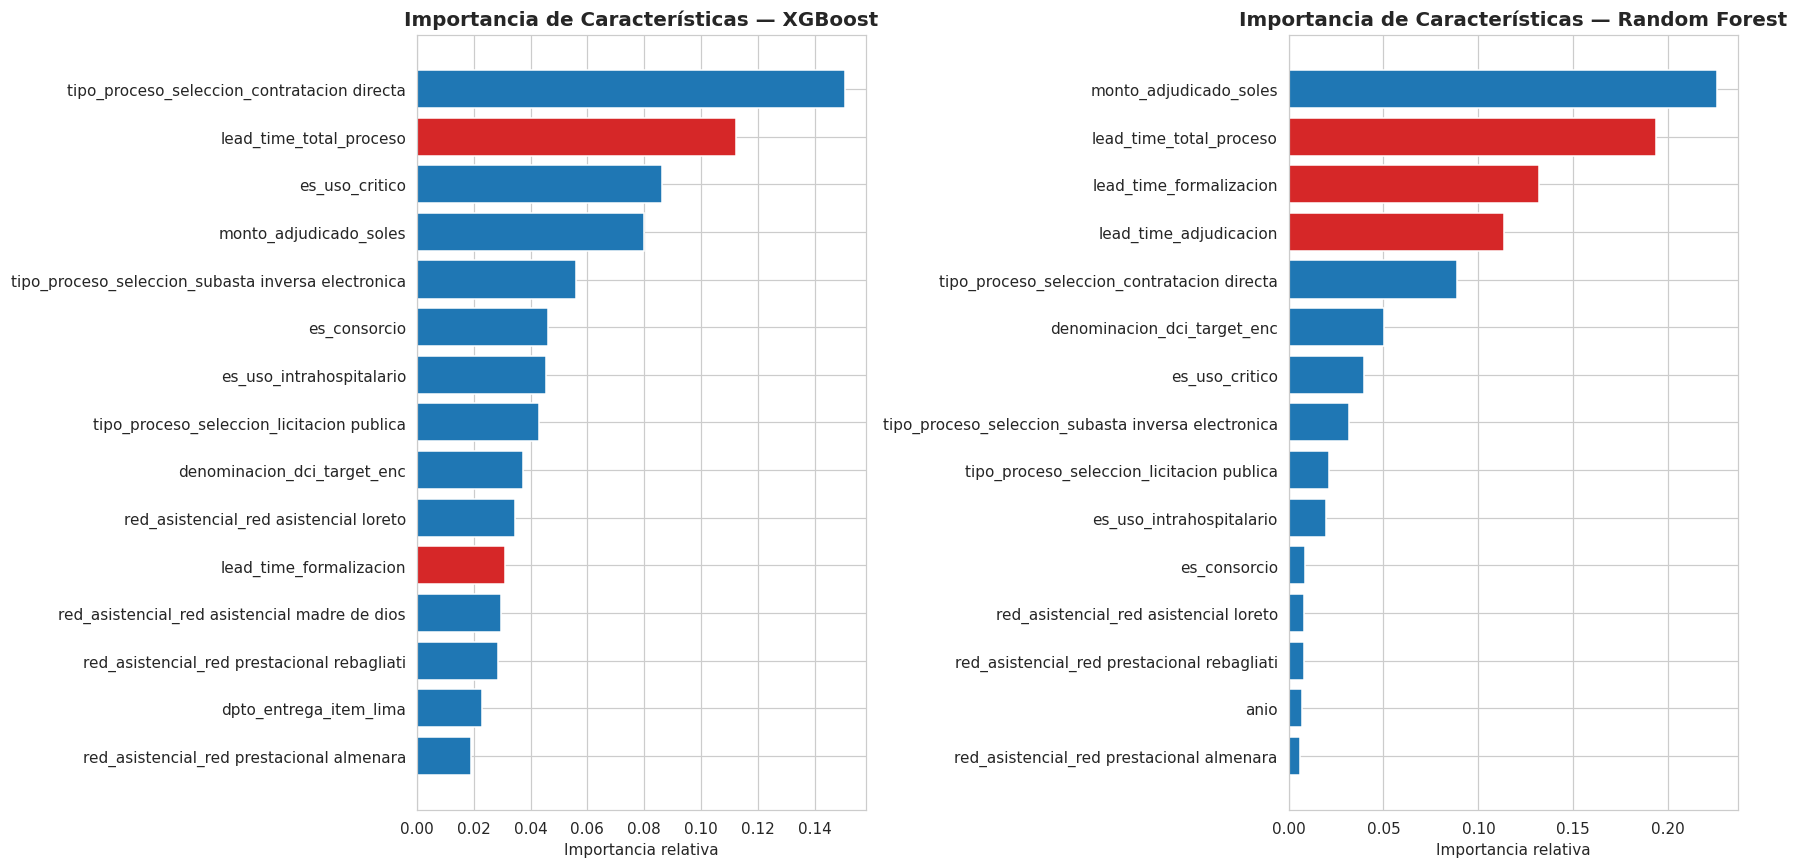

XGBoost: peso relativo acumulado de variables Lead Time = 0.1566 (15.66% del total)
Random Forest: peso relativo acumulado de variables Lead Time = 0.4387 (43.87% del total)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, model, name in zip(axes, [best_xgb, best_rf], ['XGBoost', 'Random Forest']):
    importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(15)
    colors = ['#d62728' if 'lead_time' in f else '#1f77b4' for f in importances.index]
    ax.barh(importances.index, importances.values, color=colors)
    ax.set_title(f'Importancia de Características — {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importancia relativa')

plt.tight_layout()
plt.savefig('../assets/feature_importance.png', bbox_inches='tight')
plt.show()

lt_cols = ['lead_time_adjudicacion', 'lead_time_formalizacion', 'lead_time_total_proceso']
for model, name in [(best_xgb, 'XGBoost'), (best_rf, 'Random Forest')]:
    imp = pd.Series(model.feature_importances_, index=X_train.columns)
    total_lt_weight = imp[lt_cols].sum()
    print(f"{name}: peso relativo acumulado de variables Lead Time = {total_lt_weight:.4f} "
          f"({total_lt_weight/imp.sum()*100:.2f}% del total)")

## 8. Visualización: Distribución de Lead Time por Clase (KDE)

Se comparan las distribuciones de densidad (KDE) de los tres Lead Times **crudos** (sin escalar, usando las columnas `_raw` reservadas en la partición) segmentadas por el estado del target, evidenciando visualmente si los contratos con adenda (`flag_tiene_adenda = 1`) exhiben ciclos administrativos sistemáticamente más largos.


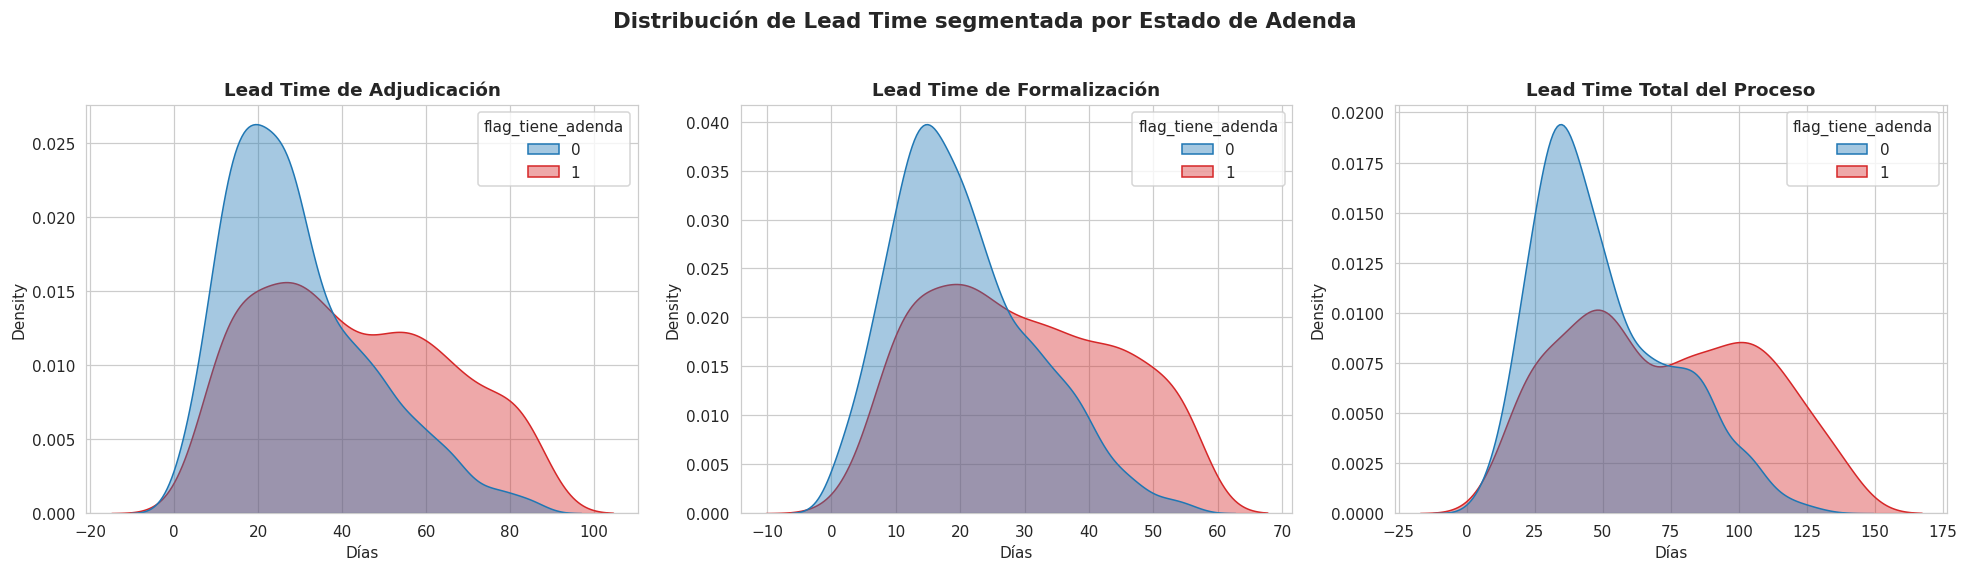

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lt_raw_cols = ['lead_time_adjudicacion_raw', 'lead_time_formalizacion_raw', 'lead_time_total_proceso_raw']
titles = ['Lead Time de Adjudicación', 'Lead Time de Formalización', 'Lead Time Total del Proceso']

plot_df = raw_test.copy()
plot_df['flag_tiene_adenda'] = y_test.values

for ax, col, title in zip(axes, lt_raw_cols, titles):
    sns.kdeplot(data=plot_df, x=col, hue='flag_tiene_adenda', fill=True, common_norm=False,
                palette={0: '#1f77b4', 1: '#d62728'}, alpha=0.4, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Días')

plt.suptitle('Distribución de Lead Time segmentada por Estado de Adenda', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../assets/kde_leadtime_by_target.png', bbox_inches='tight')
plt.show()

## 9. Visualización: Curvas ROC y Precision-Recall

Se superponen las curvas ROC y Precision-Recall de ambos estimadores sobre el mismo plano, permitiendo una comparación directa de la capacidad discriminativa global (ROC-AUC) y del comportamiento ante el desbalance de clases (Precision-Recall, más informativa que ROC cuando la clase positiva es minoritaria).


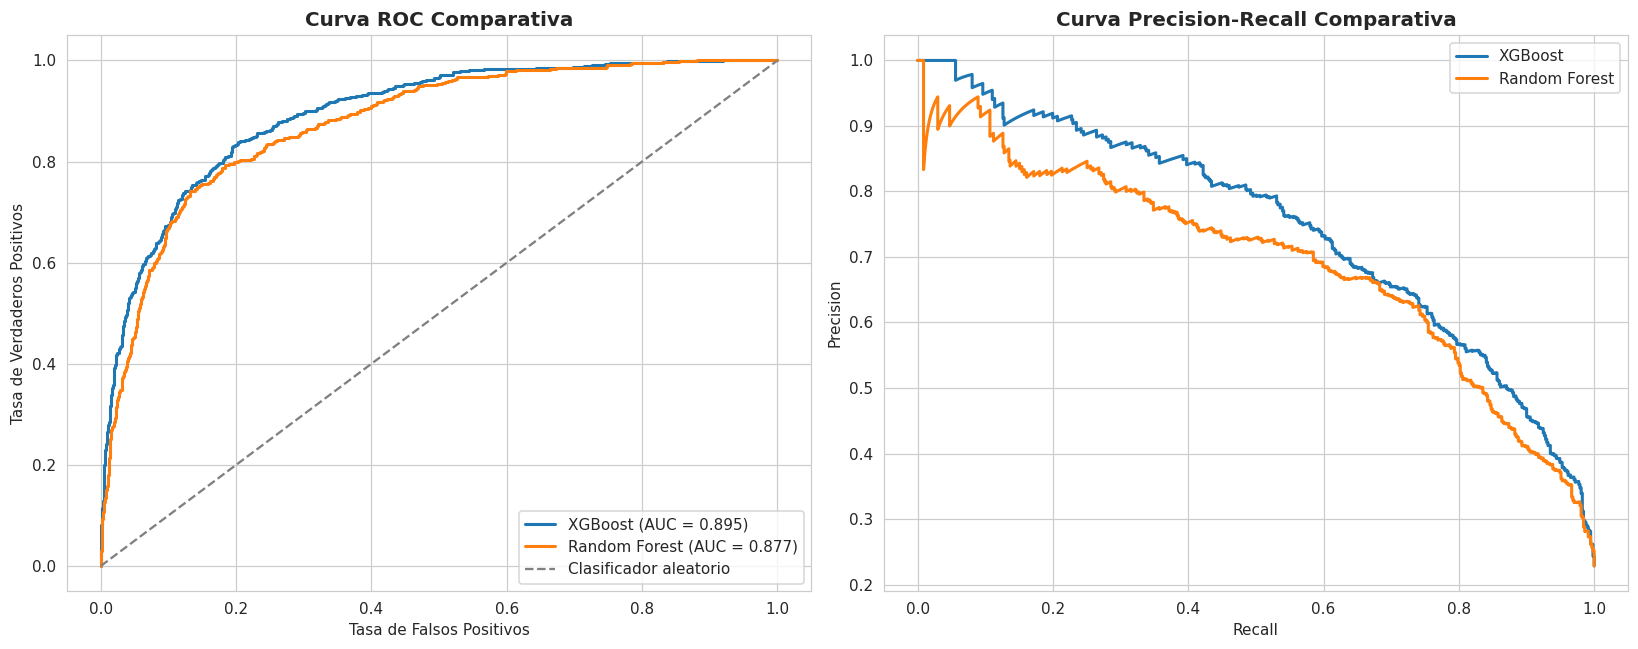

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Curva ROC ---
for proba, name, color in [(xgb_proba, 'XGBoost', '#1f77b4'), (rf_proba, 'Random Forest', '#ff7f0e')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', color=color, linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador aleatorio')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC Comparativa', fontsize=13, fontweight='bold')
axes[0].legend()

# --- Curva Precision-Recall ---
for proba, name, color in [(xgb_proba, 'XGBoost', '#1f77b4'), (rf_proba, 'Random Forest', '#ff7f0e')]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=name, color=color, linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall Comparativa', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 10. Visualización: Matriz de Confusión Normalizada

Se grafica la matriz de confusión normalizada (por fila, es decir, en términos de tasa de acierto por clase real) del modelo final seleccionado, facilitando la interpretación proporcional frente al desbalance de clases.


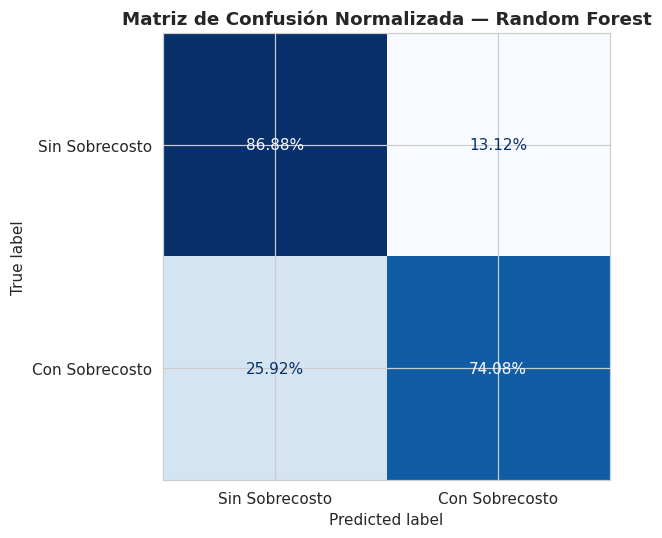

In [9]:
cm_normalized = best_cm.astype('float') / best_cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['Sin Sobrecosto', 'Con Sobrecosto'])
disp.plot(ax=ax, cmap='Blues', values_format='.2%', colorbar=False)
ax.set_title(f'Matriz de Confusión Normalizada — {best_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/confusion_matrix_normalized.png', bbox_inches='tight')
plt.show()

## 11. Visualización: Comparativa de Métricas Finales

Gráfico de barras agrupadas comparando todas las métricas de desempeño en el conjunto de prueba entre ambos ensambles.


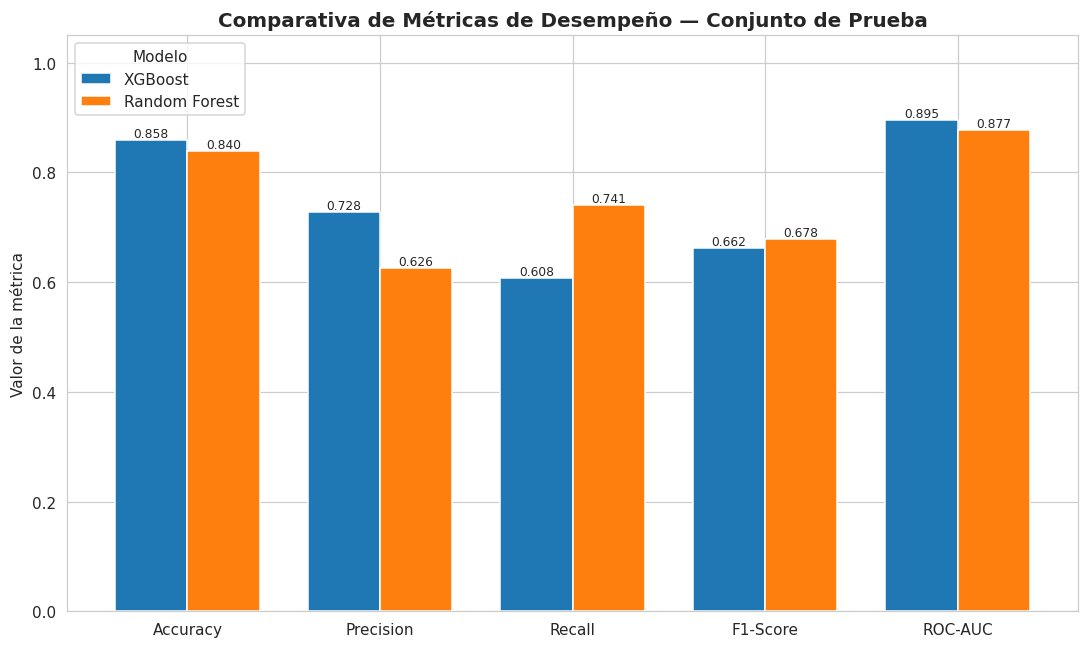

In [10]:
metrics_plot_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].T

fig, ax = plt.subplots(figsize=(10, 6))
metrics_plot_df.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'], width=0.75)
ax.set_title('Comparativa de Métricas de Desempeño — Conjunto de Prueba', fontsize=13, fontweight='bold')
ax.set_ylabel('Valor de la métrica')
ax.set_ylim(0, 1.05)
ax.legend(title='Modelo')
ax.set_xticklabels(metrics_plot_df.index, rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.savefig('../assets/metrics_comparison_bars.png', bbox_inches='tight')
plt.show()

## 12. Serialización de Artefactos

Se exportan los modelos óptimos, junto con la lista ordenada de columnas de entrenamiento (`feature_cols`), necesaria para reconstruir el vector de entrada en la aplicación Streamlit de inferencia en tiempo real.


In [11]:
joblib.dump(best_xgb, '../Modelos/best_xgboost_model.pkl')
joblib.dump(best_rf, '../Modelos/best_random_forest_model.pkl')
joblib.dump(feature_cols, '../Modelos/feature_columns.pkl')
joblib.dump(best_model_name, '../Modelos/best_model_name.pkl')
results_df.to_csv('../Modelos/test_metrics_summary.csv')

print("Artefactos serializados en 'Modelos/':")
print(" - best_xgboost_model.pkl")
print(" - best_random_forest_model.pkl")
print(" - feature_columns.pkl")
print(" - best_model_name.pkl")
print(" - test_metrics_summary.csv")
print(f"\nModelo recomendado para despliegue: {best_model_name}")

Artefactos serializados en 'Modelos/':
 - best_xgboost_model.pkl
 - best_random_forest_model.pkl
 - feature_columns.pkl
 - best_model_name.pkl
 - test_metrics_summary.csv

Modelo recomendado para despliegue: Random Forest
